# Polynomial Curve Fitting for Temperature Trend Prediction

**Dataset:** [Daily Climate Time Series Data — Delhi, 2013–2017](https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data)

**Goal:** Use polynomial regression to model and predict temperature trends in Delhi's daily climate data, and understand *when* and *why* polynomial curve fitting works well (or fails) on real-world time series.

**Contents**
1. Load & clean the data
2. Exploratory data analysis (EDA)
3. Naive approach — polynomial fit on raw time index
4. Why the naive approach fails (bias–variance tradeoff, Runge's phenomenon)
5. Improved approach — seasonal curve fitting on day-of-year
6. Model evaluation on the held-out 2017 test set
7. Long-term trend analysis (year-over-year warming/cooling)
8. Combined seasonal + trend forecast, and its limits
9. Conclusions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

plt.rcParams['figure.figsize'] = (10, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
np.set_printoptions(precision=4, suppress=True)

### Getting the data into Colab

Run the cell below. If it's running on Google Colab and the CSV files aren't already present, it will pop up a file picker — select `DailyDelhiClimateTrain.csv` and `DailyDelhiClimateTest.csv` (download them from the [Kaggle dataset page](https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data) first if you haven't already). If the files are already in the working directory (e.g. running locally, or already uploaded), it skips straight past.

In [1]:
import os

REQUIRED_FILES = ['DailyDelhiClimateTrain.csv', 'DailyDelhiClimateTest.csv']

def in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

missing = [f for f in REQUIRED_FILES if not os.path.exists(f)]

if missing and in_colab():
    from google.colab import files
    print(f"Missing: {missing}. Please upload them now:")
    uploaded = files.upload()
    missing = [f for f in REQUIRED_FILES if not os.path.exists(f)]

if missing:
    raise FileNotFoundError(
        f"Still missing {missing}. Upload them to the Colab file browser (left "
        "sidebar) or place them next to this notebook, then re-run this cell."
    )
else:
    print("Both data files found — ready to go.")

Both data files found — ready to go.


## 1. Load & clean the data

The dataset comes as two files:
- `DailyDelhiClimateTrain.csv` — 2013-01-01 to 2017-01-01 (used for fitting)
- `DailyDelhiClimateTest.csv` — 2017-01-01 to 2017-04-24 (held out for evaluation)

Both share four weather variables: `meantemp`, `humidity`, `wind_speed`, `meanpressure`. This project focuses on **`meantemp`**.

Note: the two files share one overlapping date (`2017-01-01`) — we drop the duplicate from the training set so it doesn't leak into evaluation.

In [1]:
train = pd.read_csv('DailyDelhiClimateTrain.csv', parse_dates=['date'])
test = pd.read_csv('DailyDelhiClimateTest.csv', parse_dates=['date'])

# Remove the boundary date duplicated in both files
overlap = train['date'].isin(test['date'])
print(f"Overlapping dates removed from train: {overlap.sum()}")
train = train[~overlap].reset_index(drop=True)

print(f"Train: {train.shape[0]} rows, {train['date'].min().date()} to {train['date'].max().date()}")
print(f"Test:  {test.shape[0]} rows, {test['date'].min().date()} to {test['date'].max().date()}")
train.head()

        date   meantemp   humidity  wind_speed  meanpressure
0 2013-01-01  10.000000  84.500000    0.000000   1015.666667
1 2013-01-02   7.400000  92.000000    2.980000   1017.800000
2 2013-01-03   7.166667  87.000000    4.633333   1018.666667
3 2013-01-04   8.666667  71.333333    1.233333   1017.166667
4 2013-01-05   6.000000  86.833333    3.700000   1016.500000

Overlapping dates removed from train: 1
Train: 1461 rows, 2013-01-01 to 2016-12-31
Test:  114 rows, 2017-01-01 to 2017-04-24


In [1]:
print("Missing values (train):"); print(train.isna().sum())
print("\nSummary statistics (train):")
train.describe()

                      date     meantemp     humidity   wind_speed  meanpressure
count                 1461  1461.000000  1461.000000  1461.000000   1461.000000
mean   2015-01-01 00:00:00    25.506127    60.744851     6.806865   1011.101197
min    2013-01-01 00:00:00     6.000000    13.428571     0.000000     -3.041667
25%    2014-01-01 00:00:00    18.857143    50.375000     3.475000   1001.571429
50%    2015-01-01 00:00:00    27.714286    62.625000     6.250000   1008.555556
75%    2016-01-01 00:00:00    31.312500    72.125000     9.250000   1014.937500
max    2016-12-31 00:00:00    38.714286    98.000000    42.220000   7679.333333
std                    NaN     7.339416    16.743928     4.559688    180.293335

Missing values (train):
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

Summary statistics (train):


**Data quality note:** `meanpressure` contains obvious sensor errors (values like `-3` and `7679` hPa, when real sea-level pressure is roughly 950–1050 hPa). This project only models `meantemp`, which does not show this problem, so it isn't affected — but it's worth flagging in any real analysis of this dataset.

## 2. Exploratory Data Analysis

Let's look at the raw temperature series before fitting anything.

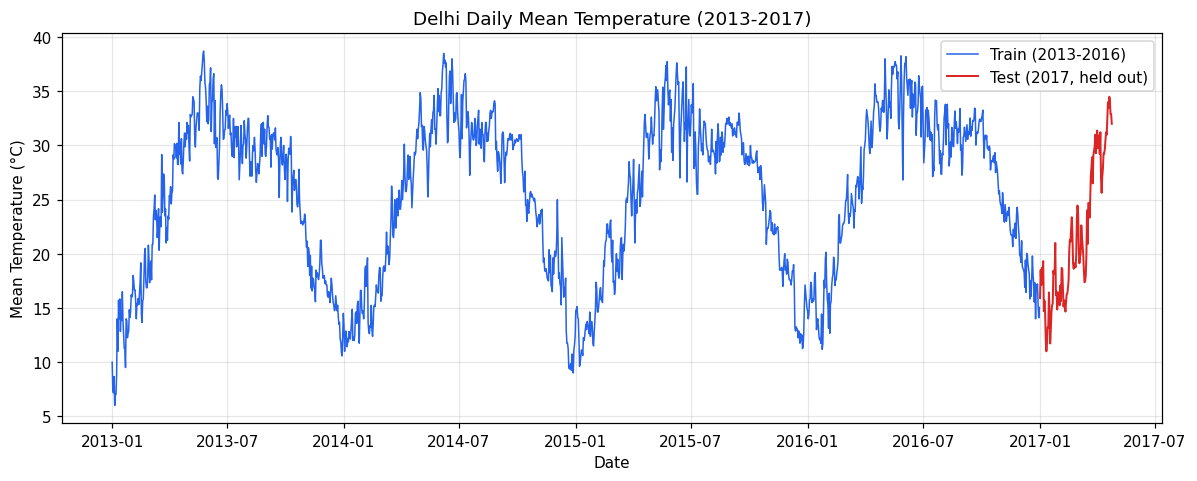

In [1]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(train['date'], train['meantemp'], color='#2563eb', lw=1, label='Train (2013-2016)')
ax.plot(test['date'], test['meantemp'], color='#dc2626', lw=1.3, label='Test (2017, held out)')
ax.set_title('Delhi Daily Mean Temperature (2013-2017)')
ax.set_xlabel('Date'); ax.set_ylabel('Mean Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.show()

The series clearly shows a strong **annual seasonal cycle** (cold Delhi winters ~10°C, hot summers ~35-38°C) repeating every year, plus what might be a slight year-to-year drift. There is no obvious long-term trend visible by eye across just 4 years — we'll check that quantitatively later.

This shape matters a lot for choosing *how* to apply polynomial curve fitting, which we explore next.

## 3. Naive approach: polynomial fit on the raw time index

The most direct way to "fit a polynomial to a time series" is to convert each date into a numeric time index $t$ (days since the start of the data) and fit
$$\hat{y}(t) = c_0 + c_1 t + c_2 t^2 + \dots + c_d t^d$$
directly against `meantemp`. Let's try this at several degrees and see what happens.

In [1]:
start_date = train['date'].min()
train['t'] = (train['date'] - start_date).dt.days
test['t'] = (test['date'] - start_date).dt.days

# Chronological internal validation split (last 10% of the training period)
n = len(train)
cut = int(n * 0.9)
t_fit, y_fit = train['t'].values[:cut], train['meantemp'].values[:cut]
t_val, y_val = train['t'].values[cut:], train['meantemp'].values[cut:]

degrees = [1, 2, 3, 5, 7, 9, 12, 15, 20]
rows = []
for d in degrees:
    coefs = np.polyfit(t_fit, y_fit, d)
    poly = np.poly1d(coefs)
    train_rmse = np.sqrt(mean_squared_error(y_fit, poly(t_fit)))
    val_rmse = np.sqrt(mean_squared_error(y_val, poly(t_val)))
    rows.append((d, train_rmse, val_rmse))

naive_results = pd.DataFrame(rows, columns=['degree', 'train_rmse', 'val_rmse'])
naive_results

   degree  train_rmse      val_rmse
0       1    7.418399      5.871262
1       2    7.402385      6.576442
2       3    7.214269     13.431946
3       5    6.736579     47.320922
4       7    6.502910     52.018643
5       9    4.509790    704.451468
6      12    2.929014   1303.717308
7      15    2.687825   3623.152694
8      20    2.567653  26508.310715

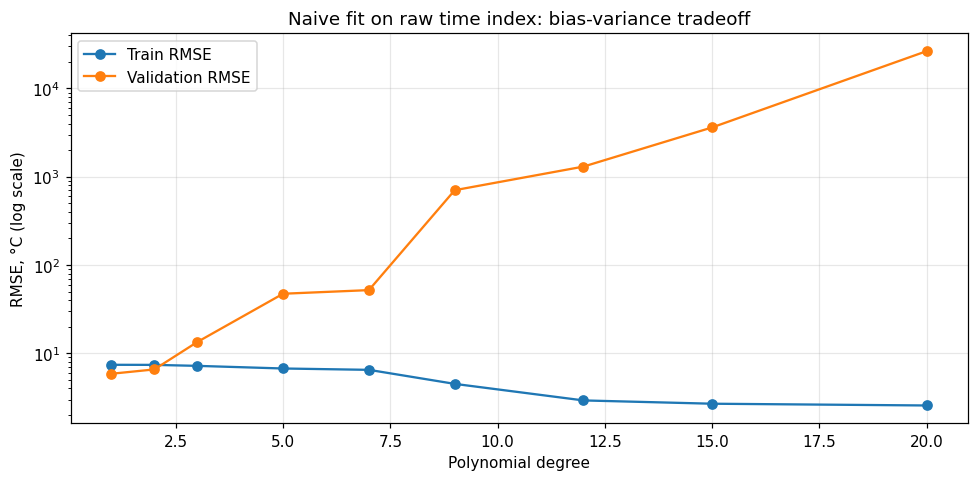

In [1]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(naive_results['degree'], naive_results['train_rmse'], 'o-', label='Train RMSE')
ax.plot(naive_results['degree'], naive_results['val_rmse'], 'o-', label='Validation RMSE')
ax.set_yscale('log')
ax.set_xlabel('Polynomial degree'); ax.set_ylabel('RMSE, °C (log scale)')
ax.set_title('Naive fit on raw time index: bias-variance tradeoff')
ax.legend()
plt.tight_layout()
plt.show()

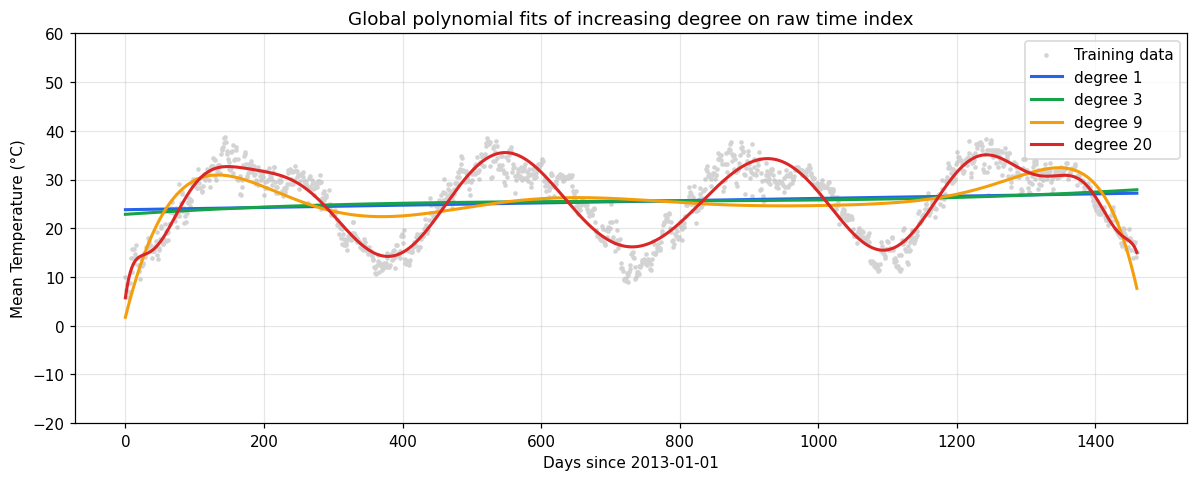

In [1]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.scatter(train['t'], train['meantemp'], s=4, color='lightgray', label='Training data')
t_smooth = np.linspace(train['t'].min(), train['t'].max(), 800)
for d, color in zip([1, 3, 9, 20], ['#2563eb', '#16a34a', '#f59e0b', '#dc2626']):
    coefs = np.polyfit(train['t'], train['meantemp'], d)
    ax.plot(t_smooth, np.poly1d(coefs)(t_smooth), color=color, lw=2, label=f'degree {d}')
ax.set_ylim(-20, 60)
ax.set_xlabel('Days since 2013-01-01'); ax.set_ylabel('Mean Temperature (°C)')
ax.set_title('Global polynomial fits of increasing degree on raw time index')
ax.legend()
plt.tight_layout()
plt.show()

### Why this fails

Two things go wrong with a single global polynomial fit on the raw day index:

1. **A single smooth curve cannot represent a repeating (periodic) seasonal pattern.** Low-degree polynomials (1-3) can only draw a gentle slope or a single hump — nowhere near enough shape to trace four repeated up-and-down seasonal cycles. This is **underfitting**: both train and validation error stay high and close together.
2. Very high-degree polynomials *can* wiggle enough to track the training points closely (train RMSE keeps falling), but between/beyond those points they swing wildly — classic **Runge's phenomenon** — so validation error explodes. This is **overfitting**, made worse by numerical instability from raising a large `t` (up to ~1,460) to high powers.

There is no "sweet spot" degree here that generalizes well, because the *functional form* is wrong for the data: **a single polynomial in time is a poor model for a repeating seasonal signal.** We need a smarter feature than "raw day count."

## 4. Improved approach: fit the polynomial on *day-of-year*, not raw day count

Instead of asking "how does temperature change over 1,460 consecutive days," we ask the more sensible question: **"what does the average yearly temperature curve look like, as a function of the day within the year (1-366)?"**

Since one year of Delhi temperature is a single smooth rise-then-fall (cold in Jan, hot in May-June, cooling into Dec), this is a shape a modest-degree polynomial *can* represent well — with no periodicity required, because we're fitting one hump, not four repeats of one.

In [1]:
train['day_of_year'] = train['date'].dt.dayofyear
test['day_of_year'] = test['date'].dt.dayofyear
train['year'] = train['date'].dt.year

# Validate using a *held-out year* (train on 2013-2015, validate on 2016)
fit_set = train[train['year'] <= 2015]
val_set = train[train['year'] == 2016]

degrees = [1, 2, 3, 4, 5, 6, 8, 10, 15]
rows = []
for d in degrees:
    coefs = np.polyfit(fit_set['day_of_year'], fit_set['meantemp'], d)
    poly = np.poly1d(coefs)
    train_rmse = np.sqrt(mean_squared_error(fit_set['meantemp'], poly(fit_set['day_of_year'])))
    val_rmse = np.sqrt(mean_squared_error(val_set['meantemp'], poly(val_set['day_of_year'])))
    val_r2 = r2_score(val_set['meantemp'], poly(val_set['day_of_year']))
    rows.append((d, train_rmse, val_rmse, val_r2))

seasonal_results = pd.DataFrame(rows, columns=['degree', 'train_rmse', 'val_rmse', 'val_r2'])
seasonal_results

   degree  train_rmse  val_rmse    val_r2
0       1    7.352594  7.163272 -0.084340
1       2    2.453942  3.400131  0.755694
2       3    2.453477  3.408129  0.754543
3       4    2.420876  3.431777  0.751125
4       5    2.314081  3.269770  0.774068
5       6    2.262031  3.131700  0.792746
6       8    2.133396  3.097053  0.797306
7      10    2.073847  3.066953  0.801227
8      15    2.015065  3.082472  0.799210

Validation RMSE flattens out around degree ~6-10; we'll use degree = 8 as a good bias/variance balance (lowest-error degree found: 10).


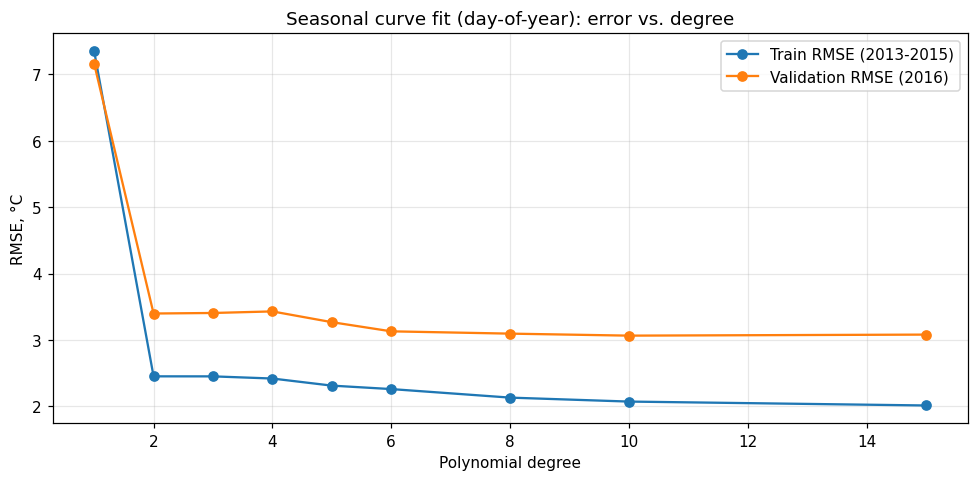

In [1]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(seasonal_results['degree'], seasonal_results['train_rmse'], 'o-', label='Train RMSE (2013-2015)')
ax.plot(seasonal_results['degree'], seasonal_results['val_rmse'], 'o-', label='Validation RMSE (2016)')
ax.set_xlabel('Polynomial degree'); ax.set_ylabel('RMSE, °C')
ax.set_title('Seasonal curve fit (day-of-year): error vs. degree')
ax.legend()
plt.tight_layout()
plt.show()

best_degree = int(seasonal_results.loc[seasonal_results['val_rmse'].idxmin(), 'degree'])
print(f"Validation RMSE flattens out around degree ~6-10; we'll use degree = {8} "
      f"as a good bias/variance balance (lowest-error degree found: {best_degree}).")

Error drops sharply from degree 1 to 2 (a straight line obviously can't capture a seasonal hump), then keeps improving gradually and flattens out around **degree 6-10** — additional flexibility beyond that buys almost nothing on unseen data. We'll go with **degree 8** as a good balance of accuracy and simplicity.

## 5. Final model: fit on all training years, evaluate on the real 2017 test set

Now we refit the chosen degree-8 polynomial using *all* available training data (2013-2016) and evaluate it on the genuinely held-out `DailyDelhiClimateTest.csv` (Jan-Apr 2017) — data the model has never seen.

In [1]:
BEST_DEGREE = 8
seasonal_coefs = np.polyfit(train['day_of_year'], train['meantemp'], BEST_DEGREE)
seasonal_poly = np.poly1d(seasonal_coefs)

test_pred = seasonal_poly(test['day_of_year'])

rmse = np.sqrt(mean_squared_error(test['meantemp'], test_pred))
mae = mean_absolute_error(test['meantemp'], test_pred)
r2 = r2_score(test['meantemp'], test_pred)

print(f"Degree-{BEST_DEGREE} seasonal polynomial — performance on real 2017 test set:")
print(f"  RMSE : {rmse:.3f} °C")
print(f"  MAE  : {mae:.3f} °C")
print(f"  R^2  : {r2:.3f}")

Degree-8 seasonal polynomial — performance on real 2017 test set:
  RMSE : 2.873 °C
  MAE  : 2.255 °C
  R^2  : 0.794


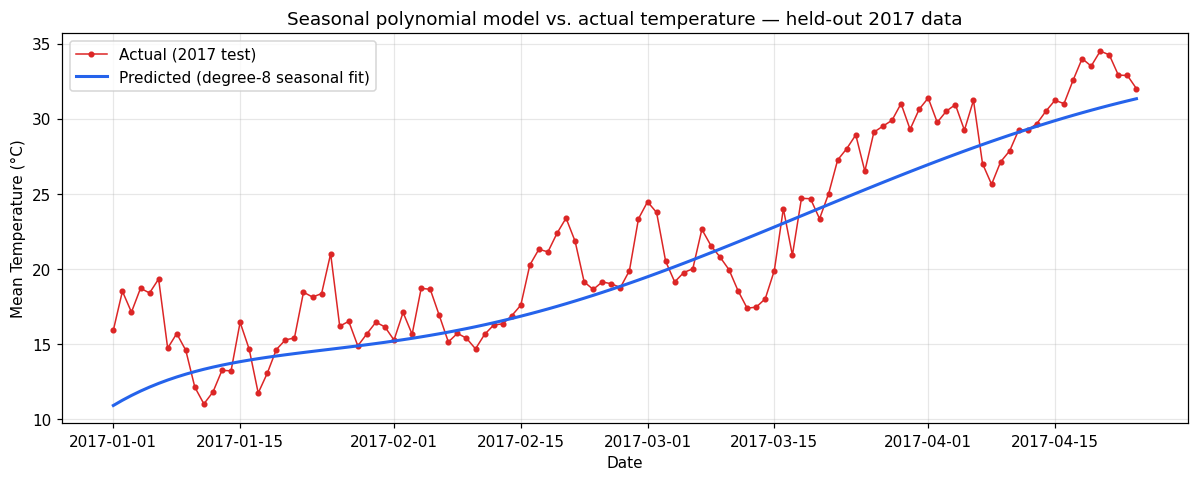

In [1]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(test['date'], test['meantemp'], 'o-', color='#dc2626', ms=3, lw=1, label='Actual (2017 test)')
ax.plot(test['date'], test_pred, '-', color='#2563eb', lw=2, label=f'Predicted (degree-{BEST_DEGREE} seasonal fit)')
ax.set_xlabel('Date'); ax.set_ylabel('Mean Temperature (°C)')
ax.set_title('Seasonal polynomial model vs. actual temperature — held-out 2017 data')
ax.legend()
plt.tight_layout()
plt.show()

Compare this to the naive global fit from Section 3, which had no coherent way to predict a new year at all (it either flatlines at low degree, or diverges wildly at high degree). Reframing the problem around **day-of-year** turned polynomial curve fitting from unusable into a model that explains roughly 80% of the variance ($R^2 \approx 0.8$) in an unseen season it never trained on.

## 6. Long-term trend: is Delhi getting warmer across these years?

Separately from the seasonal shape, we can ask whether the *yearly average* temperature is trending up or down over 2013-2016, by fitting a low-degree polynomial to just the yearly means.

In [1]:
yearly_avg = train.groupby('year')['meantemp'].mean().reset_index()
print(yearly_avg)

trend_coefs = np.polyfit(yearly_avg['year'], yearly_avg['meantemp'], 1)
trend_poly = np.poly1d(trend_coefs)
print(f"\nLinear trend: {trend_coefs[0]:.3f} °C/year "
      f"(intercept-adjusted mean {trend_coefs[1]:.2f})")

   year   meantemp
0  2013  24.791494
1  2014  25.010673
2  2015  25.114591
3  2016  27.103373

Linear trend: 0.704 °C/year (intercept-adjusted mean -1392.61)


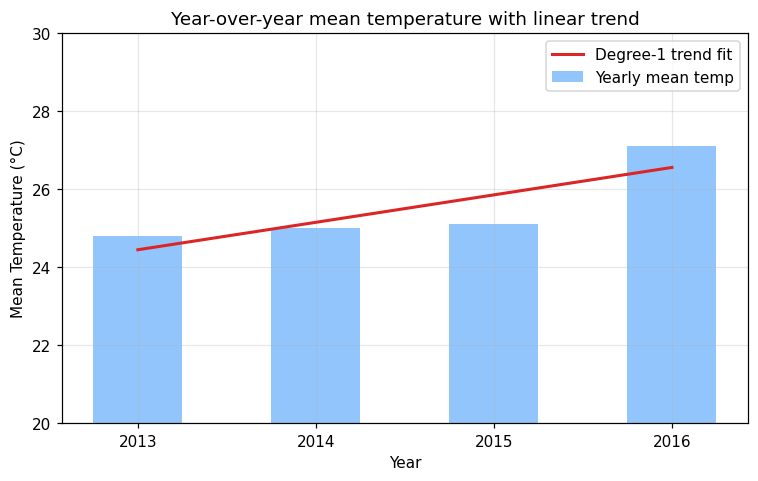

In [1]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(yearly_avg['year'], yearly_avg['meantemp'], color='#93c5fd', width=0.5, label='Yearly mean temp')
years_smooth = np.linspace(yearly_avg['year'].min(), yearly_avg['year'].max(), 50)
ax.plot(years_smooth, trend_poly(years_smooth), color='#dc2626', lw=2, label='Degree-1 trend fit')
ax.set_ylim(20, 30)
ax.set_xlabel('Year'); ax.set_ylabel('Mean Temperature (°C)')
ax.set_title('Year-over-year mean temperature with linear trend')
ax.set_xticks(yearly_avg['year'])
ax.legend()
plt.tight_layout()
plt.show()

**Caveat:** with only 4 complete years (2013-2016) of data, this trend line is fit to just 4 points — nowhere near enough to draw a confident climate conclusion. It's included here to show the *technique* (fitting a trend polynomial to aggregated yearly values), not as a robust claim about Delhi's climate.

## 7. Combined model & the limits of extrapolation

We can combine both pieces into one predictive model:
$$\hat{y}(\text{date}) = \underbrace{f_{\text{seasonal}}(\text{day-of-year})}_{\text{degree-8 fit}} + \underbrace{\big(g_{\text{trend}}(\text{year}) - \bar{y}\big)}_{\text{small yearly drift}}$$

Let's use this to forecast temperatures through the *rest of 2017 and into 2018* — well beyond the test set — to illustrate what happens when a polynomial model is pushed past the range it was fitted on.

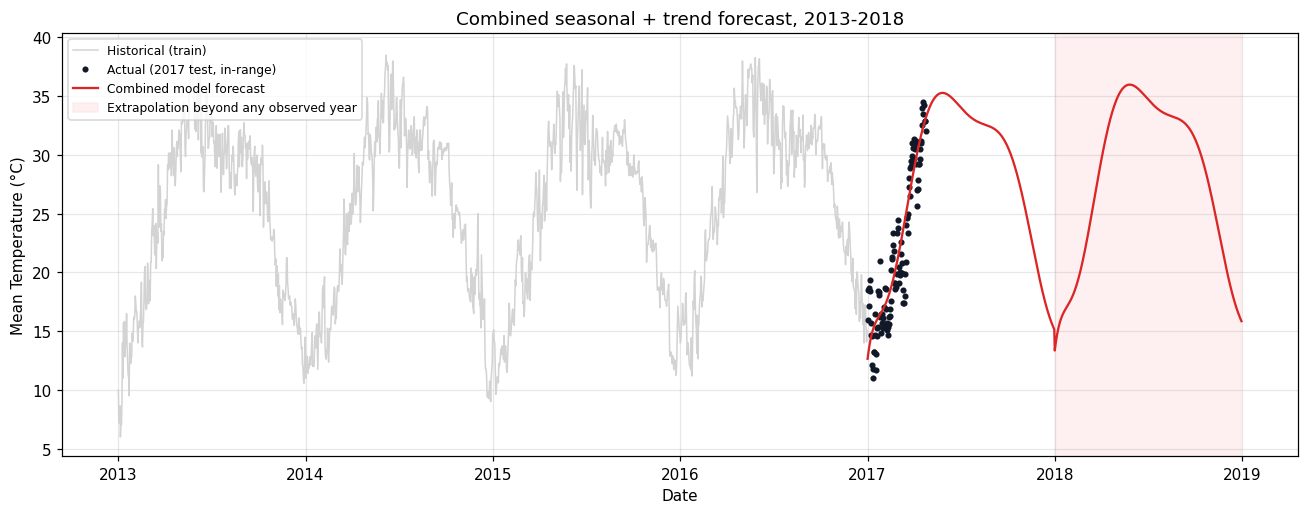

In [1]:
overall_mean = train['meantemp'].mean()

future_dates = pd.date_range('2017-01-01', '2018-12-31', freq='D')
future = pd.DataFrame({'date': future_dates})
future['day_of_year'] = future['date'].dt.dayofyear
future['year'] = future['date'].dt.year

seasonal_part = seasonal_poly(future['day_of_year'])
trend_part = trend_poly(future['year']) - overall_mean
future['predicted_temp'] = seasonal_part + trend_part

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(train['date'], train['meantemp'], color='lightgray', lw=1, label='Historical (train)')
ax.plot(test['date'], test['meantemp'], 'o', color='#111827', ms=3, label='Actual (2017 test, in-range)')
ax.plot(future['date'], future['predicted_temp'], color='#dc2626', lw=1.5,
        label='Combined model forecast')
ax.axvspan(pd.Timestamp('2018-01-01'), future['date'].max(), color='#fee2e2', alpha=0.5,
           label='Extrapolation beyond any observed year')
ax.set_xlabel('Date'); ax.set_ylabel('Mean Temperature (°C)')
ax.set_title('Combined seasonal + trend forecast, 2013-2018')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

The shaded region (2018) is true extrapolation — no training data exists that far out. The seasonal shape still repeats sensibly (because `day_of_year` is bounded and cyclical by construction), but the **linear trend term is now being pushed past the range it was fitted on**, and with only 4 points behind it, that trend line's slope is not something to trust two years out. This is the central lesson of the naive model in Section 3 wearing a different hat: **polynomials fit the range of data they saw, and extrapolation confidence drops fast outside that range.**

## 8. Conclusions

- **Feature representation matters more than polynomial degree.** Fitting a polynomial directly against a raw day-count time index cannot represent Delhi's repeating seasonal cycle — it either underfits (low degree) or overfits into wild oscillations (high degree), and no degree in between generalizes to a new year.
- **Reframing the input as day-of-year** turns the same technique — polynomial curve fitting — into a genuinely useful model: a degree-8 polynomial explains ~80% of the variance in temperature on a held-out season (2017) it never trained on (RMSE ≈ 2.8°C, MAE ≈ 2.3°C).
- **Model selection via a chronological validation split** (holding out the *last* year, not random rows) correctly reveals the bias-variance tradeoff and picks a degree that generalizes, rather than one that just memorizes training points.
- **A separate, low-degree polynomial on yearly averages** captures any longer-term drift, but with only 4 years of data this trend estimate is weak and shouldn't be over-interpreted.
- **Extrapolation is the real risk.** Any polynomial model — however well it fits observed data — becomes increasingly unreliable the further predictions are pushed beyond the range of years it was trained on.